# Fake News Detection — Complete BERT / DistilBERT Training Notebook

This notebook is for the **BERT training part** of the fake news detection project.

It includes:

1.  loading and validation  
2. Label encoding  
3. Safe sampling for fast training  
4. Train/validation/test split  
5. Hugging Face tokenizer  
6. DistilBERT sequence classification  
7. Training configuration  
8. Evaluation metrics  
9. Confusion matrix  
10. ROC curve  
11. Training history Datasetvisualization  
12. Real prediction demo  
13. Model saving  

Recommended model for deadline: **DistilBERT** because it is faster than full BERT and still uses transformer-based contextual embeddings.

In [2]:
# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import os
import re
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


In [3]:
# ============================================================
# 3. SET FILE PATHS AND TRAINING SETTINGS
# ============================================================

DATA_PATH = "C:/Users/ashok\Downloads/generated_fake_news_dataset/full_fake_news_dataset.csv"

RESULTS_DIR = "bert_results"
MODEL_OUTPUT_DIR = os.path.join(RESULTS_DIR, "distilbert_fake_news_model")

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)

# For deadline safety:
# If you have GPU, you can use 20000 or 60000.
# If CPU only, use 3000 to 8000.
MAX_RECORDS_FOR_BERT = 10000

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256
NUM_EPOCHS = 2
BATCH_SIZE = 8

print("Dataset:", DATA_PATH)
print("Model:", MODEL_NAME)
print("Max BERT records:", MAX_RECORDS_FOR_BERT)

Dataset: C:/Users/ashok\Downloads/generated_fake_news_dataset/full_fake_news_dataset.csv
Model: distilbert-base-uncased
Max BERT records: 10000


In [4]:
# ============================================================
# 4. LOAD DATASET
# ============================================================

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset file not found: {DATA_PATH}\n"
        "Update DATA_PATH to your actual CSV file."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded.")
print("Shape:", df.shape)
display(df.head())
print(df.columns.tolist())

Dataset loaded.
Shape: (20771, 12)


,title,text,cleaned_text,label,source,url,publish_date,text_hash,word_count,text_length,capital_ratio,punctuation_count
0,A new Taliban law opens the door to child marr...,A new Taliban law opens the door to child marr...,new taliban law open door child marriage even ...,real,NPR,https://www.npr.org/2026/05/22/nx-s1-5831001/c...,2026-05-22 00:00:00,1413553c78f5e272457e42e3d5468e0c,737,5450,0.024791,142
1,"Oostvaardersplassen, o experimento holandês qu...",O experimento na Holanda que transformou santu...,experimento holanda que transformou santu rio ...,real,BBC,https://www.bbc.com/portuguese/articles/c4g0y9...,NaN,bf60abbe3ef6761e4b4676e458131ecd,2458,17390,0.018033,439
2,Czym jest Aufguss i dlaczego półnagie saunowan...,"Nowy europejski trend zdrowotny: gorące, półna...",nowy europejski trend zdrowotny gor nagie rytu...,real,BBC,https://www.bbc.com/polska/articles/c070942eyyyo,NaN,a63457e28683ee1d7960571eb7e1577c,498,3543,0.030797,83
3,IPL 2026: Vaibhav Sooryavanshi stuns again wit...,Teenage sensation Vaibhav Sooryavanshi produce...,teenage sensation vaibhav sooryavanshi produce...,real,BBC,https://www.bbc.com/sport/cricket/articles/cwy...,NaN,3072d4d7bf02601792a2a3194ba2d924,130,920,0.034139,27
4,Oreo is bringing zero-sugar cookies to the US,Add AP News as your preferred source to see mo...,add news preferred source see story google add...,real,AP,https://apnews.com/article/oreos-zero-sugar-f5...,2025-12-09 20:27:07,c14a0da79608177cf69657740a3c2792,244,1666,0.037537,52


['title', 'text', 'cleaned_text', 'label', 'source', 'url', 'publish_date', 'text_hash', 'word_count', 'text_length', 'capital_ratio', 'punctuation_count']


In [5]:
# ============================================================
# 5. STANDARDIZE TEXT AND LABEL COLUMNS
# ============================================================

if "text" not in df.columns:
    if "cleaned_text" in df.columns:
        df["text"] = df["cleaned_text"]
    elif "content" in df.columns:
        df.rename(columns={"content": "text"}, inplace=True)
    elif "article" in df.columns:
        df.rename(columns={"article": "text"}, inplace=True)
    else:
        raise ValueError("No usable text column found.")

if "label" not in df.columns:
    raise ValueError("No label column found.")

df = df.dropna(subset=["text", "label"]).copy()

df["label"] = df["label"].astype(str).str.lower().str.strip()

label_map = {
    "fake": 0,
    "false": 0,
    "0": 0,
    "real": 1,
    "true": 1,
    "1": 1
}

df["labels"] = df["label"].map(label_map)

if df["labels"].isnull().any():
    print("Unique labels:", df["label"].unique())
    raise ValueError("Labels must be fake/real or 0/1.")

df["text"] = df["text"].astype(str)

# Remove very short raw texts
df["raw_word_count"] = df["text"].apply(lambda x: len(x.split()))
df = df[df["raw_word_count"] >= 40].copy()

print("After validation:", df.shape)
print(df["labels"].value_counts())

After validation: (20771, 14)
labels
0    14528
1     6243
Name: count, dtype: int64


In [6]:
# ============================================================
# 6. BALANCED SAMPLING FOR FAST BERT TRAINING
# ============================================================


if len(df) > MAX_RECORDS_FOR_BERT:
    per_class = MAX_RECORDS_FOR_BERT // 2

    fake_sample = df[df["labels"] == 0].sample(
        n=min(per_class, len(df[df["labels"] == 0])),
        random_state=RANDOM_STATE
    )

    real_sample = df[df["labels"] == 1].sample(
        n=min(per_class, len(df[df["labels"] == 1])),
        random_state=RANDOM_STATE
    )

    bert_df = pd.concat([fake_sample, real_sample], ignore_index=True)
    bert_df = bert_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
else:
    bert_df = df.copy()

print("BERT training dataset shape:", bert_df.shape)
print(bert_df["labels"].value_counts())

BERT training dataset shape: (10000, 14)
labels
1    5000
0    5000
Name: count, dtype: int64


In [7]:
# ============================================================
# 7. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

train_df, temp_df = train_test_split(
    bert_df,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=bert_df["labels"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_df["labels"]
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain labels:")
print(train_df["labels"].value_counts())
print("\nValidation labels:")
print(val_df["labels"].value_counts())
print("\nTest labels:")
print(test_df["labels"].value_counts())

Train: (7000, 14)
Validation: (1500, 14)
Test: (1500, 14)

Train labels:
labels
1    3500
0    3500
Name: count, dtype: int64

Validation labels:
labels
1    750
0    750
Name: count, dtype: int64

Test labels:
labels
0    750
1    750
Name: count, dtype: int64


In [8]:
# ============================================================
# 8. CREATE HUGGING FACE DATASETS
# ============================================================

train_dataset = Dataset.from_pandas(train_df[["text", "labels"]].reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df[["text", "labels"]].reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df[["text", "labels"]].reset_index(drop=True))

dataset_dict = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset
})

print(dataset_dict)

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 7000
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 1500
    })
})


In [9]:
# ============================================================
# 9. TOKENIZATION
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_datasets = dataset_dict.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(tokenized_datasets)

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1500
    })
})


In [10]:
# ============================================================
# 10. LOAD DISTILBERT MODEL
# ============================================================

id2label = {0: "Fake", 1: "Real"}
label2id = {"Fake": 0, "Real": 1}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

model.to(device)

print("Model loaded successfully.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully.


In [11]:
# ============================================================
# 11. DEFINE EVALUATION METRICS
# ============================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    try:
        probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
        roc_auc = roc_auc_score(labels, probs)
    except Exception:
        roc_auc = 0.0

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc
    }

print("Metrics function ready.")

Metrics function ready.


In [36]:
from transformers import EarlyStoppingCallback

In [40]:
training_args = TrainingArguments(
    output_dir="./bert_checkpoints",

    eval_strategy="epoch",      # or evaluation_strategy="epoch"
    save_strategy="epoch",
    logging_strategy="epoch",

    num_train_epochs=5,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    save_total_limit=2,
    report_to="none"
)

In [43]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

print("Trainer created.")

Trainer created.


In [44]:
# ============================================================
# 14. TRAIN BERT MODEL
# ============================================================

train_result = trainer.train()

print("Training completed.")
print(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.122896,0.220150,0.947333,0.966620,0.926667,0.946222,0.985433
2,0.079347,0.238779,0.949333,0.934278,0.966667,0.950197,0.986560


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Training completed.
TrainOutput(global_step=1750, training_loss=0.10112125941685268, metrics={'train_runtime': 10194.9968, 'train_samples_per_second': 3.433, 'train_steps_per_second': 0.429, 'total_flos': 927271790592000.0, 'train_loss': 0.10112125941685268, 'epoch': 2.0})


In [46]:
# ============================================================
# EVALUATE ALREADY TRAINED MODEL AND SAVE METRICS
# ============================================================

import os
import json

# Define folders
RESULTS_DIR = "./bert_results"
MODEL_DIR = "./saved_bert_model"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("Validation Evaluation:")
val_pred = trainer.predict(tokenized_datasets["validation"])
val_metrics = val_pred.metrics
print(val_metrics)

print("\nTest Evaluation:")
test_pred = trainer.predict(tokenized_datasets["test"])
test_metrics = test_pred.metrics
print(test_metrics)

metrics_path = os.path.join(RESULTS_DIR, "bert_evaluation_metrics.json")

with open(metrics_path, "w") as f:
    json.dump(
        {
            "validation": val_metrics,
            "test": test_metrics
        },
        f,
        indent=4
    )

print("\nMetrics saved:", metrics_path)

# Save already trained model
trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

print("Model saved:", MODEL_DIR)

Validation Evaluation:


{'test_loss': 0.21971304714679718, 'test_accuracy': 0.9473333333333334, 'test_precision': 0.9666203059805285, 'test_recall': 0.9266666666666666, 'test_f1': 0.9462219196732471, 'test_roc_auc': 0.9854311111111111, 'test_runtime': 168.7474, 'test_samples_per_second': 8.889, 'test_steps_per_second': 1.114}

Test Evaluation:


{'test_loss': 0.24844233691692352, 'test_accuracy': 0.9393333333333334, 'test_precision': 0.953232462173315, 'test_recall': 0.924, 'test_f1': 0.9383886255924171, 'test_roc_auc': 0.981352, 'test_runtime': 181.9679, 'test_samples_per_second': 8.243, 'test_steps_per_second': 1.033}

Metrics saved: ./bert_results\bert_evaluation_metrics.json


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved: ./saved_bert_model


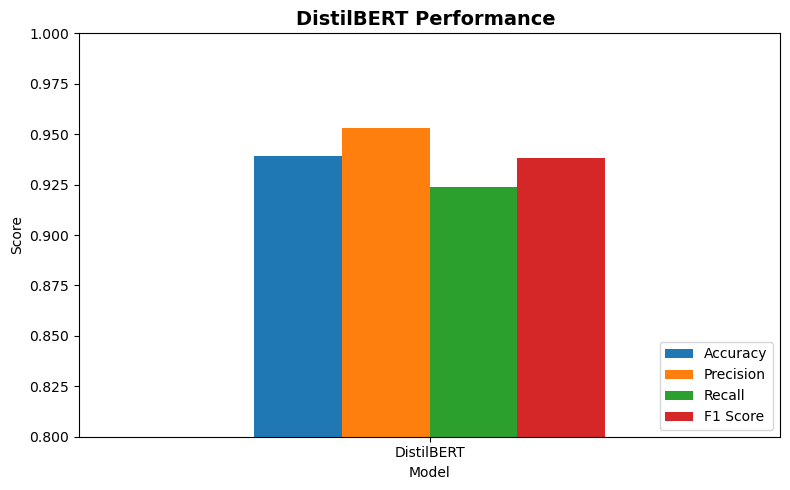

In [54]:

# Collect metrics automatically from test_metrics
bert_results_df = pd.DataFrame({
    "Model": ["DistilBERT"],
    "Accuracy": [test_metrics["test_accuracy"]],
    "Precision": [test_metrics["test_precision"]],
    "Recall": [test_metrics["test_recall"]],
    "F1 Score": [test_metrics["test_f1"]]
})

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

plot_df = bert_results_df.set_index("Model")[metrics]

ax = plot_df.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("DistilBERT Performance ", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.ylim(0.80, 1.00)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# 16. TEST PREDICTIONS AND CLASSIFICATION REPORT
# ============================================================

pred_output = trainer.predict(tokenized_datasets["test"])

logits = pred_output.predictions
y_true = pred_output.label_ids
y_pred = np.argmax(logits, axis=1)
y_prob = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]

print(classification_report(y_true, y_pred, target_names=["Fake", "Real"]))

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=["Fake", "Real"],
    output_dict=True
)

pd.DataFrame(report_dict).transpose().to_csv(
    os.path.join(RESULTS_DIR, "bert_classification_report.csv")
)

              precision    recall  f1-score   support

        Fake       0.92      0.96      0.94       750
        Real       0.96      0.91      0.93       750

    accuracy                           0.94      1500
   macro avg       0.94      0.94      0.94      1500
weighted avg       0.94      0.94      0.94      1500



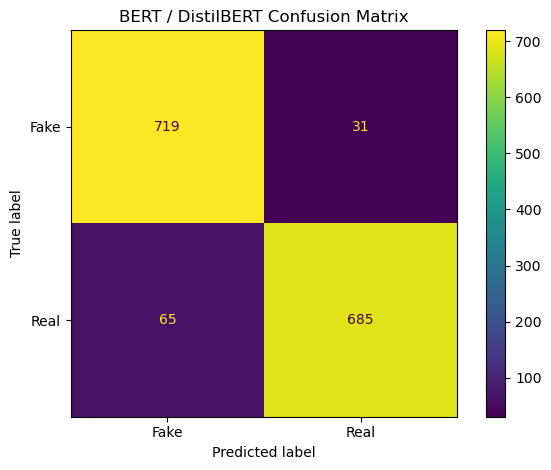

[[719  31]
 [ 65 685]]


In [21]:
# ============================================================
# 17. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

disp.plot()
plt.title("BERT / DistilBERT Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "bert_confusion_matrix.png"), dpi=300)
plt.show()

print(cm)

ROC-AUC: 0.9818453333333335


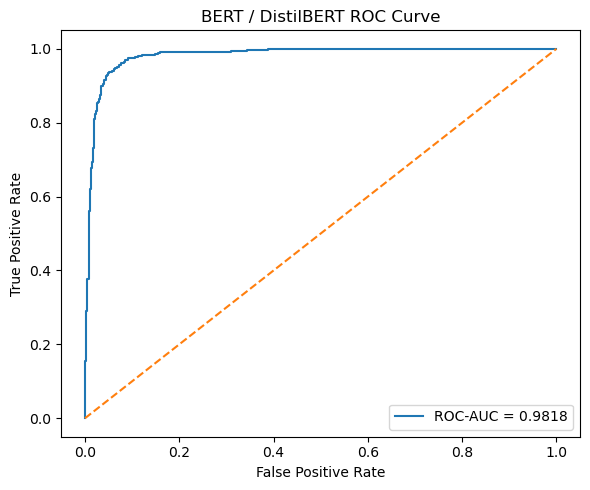

In [22]:
# ============================================================
# 18. ROC CURVE
# ============================================================

roc_auc = roc_auc_score(y_true, y_prob)
print("ROC-AUC:", roc_auc)

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("BERT / DistilBERT ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "bert_roc_curve.png"), dpi=300)
plt.show()

No eval_loss found. Validation loss was not logged during training.


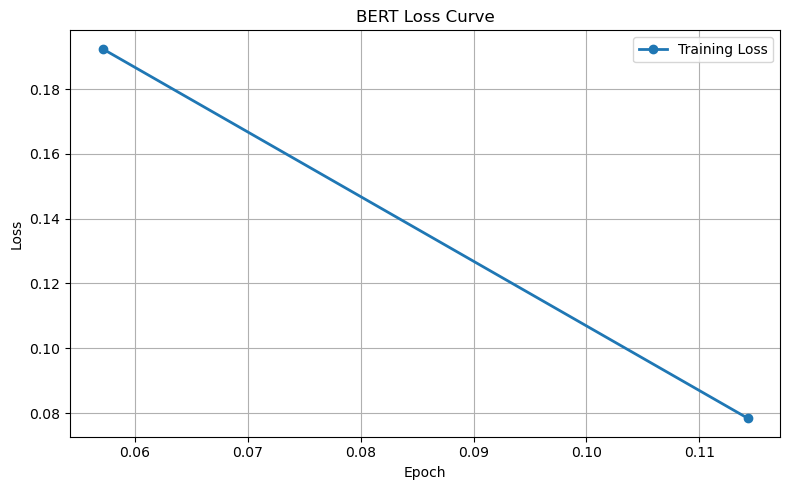

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

history_df = pd.DataFrame(trainer.state.log_history)

plt.figure(figsize=(8, 5))

# Training loss
if "loss" in history_df.columns:
    train_loss = history_df[history_df["loss"].notna()].copy()
    plt.plot(
        train_loss["epoch"],
        train_loss["loss"],
        marker="o",
        linewidth=2,
        label="Training Loss"
    )

# Validation loss
if "eval_loss" in history_df.columns:
    val_loss = history_df[history_df["eval_loss"].notna()].copy()
    plt.plot(
        val_loss["epoch"],
        val_loss["eval_loss"],
        marker="s",
        linewidth=2,
        label="Validation Loss"
    )
else:
    print("No eval_loss found. Validation loss was not logged during training.")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BERT Loss Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# 20. REAL PREDICTION DEMONSTRATION
# ============================================================

def predict_with_bert(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
        padding=True
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]

    pred_id = int(np.argmax(probs))
    pred_label = id2label[pred_id]
    confidence = float(np.max(probs))

    return {
        "prediction": pred_label,
        "confidence": confidence,
        "fake_probability": float(probs[0]),
        "real_probability": float(probs[1])
    }

sample_text = '''
Government officials released a public statement today after reviewing expert reports
and confirmed that the new policy will be implemented in phases.
'''

result = predict_with_bert(sample_text)
print(result)

{'prediction': 'Fake', 'confidence': 0.9929001331329346, 'fake_probability': 0.9929001331329346, 'real_probability': 0.007099856156855822}


In [30]:
# ============================================================
# 21. SAVE FINAL BERT MODEL
# ============================================================

final_save_dir = os.path.join(RESULTS_DIR, "final_distilbert_fake_news_model")

trainer.save_model(final_save_dir)
tokenizer.save_pretrained(final_save_dir)

metadata = {
    "model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "num_epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "max_records_for_bert": MAX_RECORDS_FOR_BERT,
    "device": device,
    "label_mapping": {"0": "Fake", "1": "Real"},
    "final_save_dir": final_save_dir
}

with open(os.path.join(RESULTS_DIR, "bert_model_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=4)

print("Final BERT model saved to:", final_save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final BERT model saved to: ./bert_results\final_distilbert_fake_news_model
